In [ ]:
import os
import zipfile
import random
import shutil
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from shutil import copyfile
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16, ResNet50, ResNet101, InceptionResNetV2,DenseNet169,ResNet50V2
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Average
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [ ]:
import pandas as pd
import tensorflow
import numpy as np
from keras.models import Sequential
from keras import optimizers
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
from keras.applications import MobileNetV2

from tensorflow.keras.applications import VGG16, ResNet50, ResNet101, InceptionResNetV2,MobileNetV2

In [ ]:
!pip install opendatasets
! pip install kaggle


In [ ]:
import opendatasets as od
import pandas
#{"username":"arshsinghkhanka","key":"939acc522ce78e008cdc779fe5381cf7"}
od.download(
    "https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000")

Skipping, found downloaded files in "./skin-cancer-mnist-ham10000" (use force=True to force download)


In [ ]:

from sklearn.metrics import confusion_matrix



from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

In [ ]:
base_model=ResNet50V2(include_top=False, weights="imagenet", input_shape=(224,224,3))

In [ ]:

data=pd.read_csv("/content/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")
data['image_full_name']=data['image_id']+'.jpg'
X=data[['image_full_name','dx','lesion_id']]

In [ ]:
X.sample(5)

,image_full_name,dx,lesion_id
7246,ISIC_0028214.jpg,nv,HAM_0006187
7260,ISIC_0030765.jpg,nv,HAM_0003188
2294,ISIC_0031295.jpg,mel,HAM_0006832
1198,ISIC_0029973.jpg,df,HAM_0002045
696,ISIC_0027017.jpg,bkl,HAM_0003183


In [ ]:
from sklearn.model_selection import train_test_split
Y=X.pop('dx').to_frame()
X_train, X_test, y_train, y_test   = train_test_split(X,Y, test_size=0.17, random_state=42)
X_train,X_val,y_train,y_val        =train_test_split(X_train, y_train, test_size=0.17, random_state=42)

In [ ]:
train=pd.concat([X_train,y_train],axis=1)
val=pd.concat([X_val,y_val],axis=1)
test=pd.concat([X_test,y_test],axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder= LabelEncoder()
encoder.fit(val['dx'])
name_as_indexes_train=encoder.transform(val['dx'])
val['label']=name_as_indexes_train

In [ ]:
encoder=LabelEncoder()
encoder.fit(test['dx'])
name_as_indexes_test=encoder.transform(test['dx'])
test['label']=name_as_indexes_test

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_generator = ImageDataGenerator(rescale = 1./255,
                                     rotation_range=10,
                                     zoom_range = 0.1,
                                     width_shift_range=0.0,  height_shift_range=0.0)

In [ ]:



import os
import shutil

# Define the source and destination folders (replace with your actual paths)
source_folder = "/content/skin-cancer-mnist-ham10000/HAM10000_images_part_1"
destination_folder = "/content/skin-cancer-mnist-ham10000/All_images"

# Copy all files from source to destination
for filename in os.listdir(source_folder):
  # Skip hidden files (starting with .)
  if not filename.startswith('.'):
    source_file = os.path.join(source_folder, filename)
    destination_file = os.path.join(destination_folder, filename)
    shutil.copy2(source_file, destination_file)  # Use copy2 to preserve file metadata

print(f"Files copied from {source_folder} to {destination_folder}")

Files copied from /content/skin-cancer-mnist-ham10000/HAM10000_images_part_1 to /content/skin-cancer-mnist-ham10000/All_images


In [ ]:
source_folder = "/content/skin-cancer-mnist-ham10000/HAM10000_images_part_2"
destination_folder = "/content/skin-cancer-mnist-ham10000/All_images"

# Copy all files from source to destination
for filename in os.listdir(source_folder):
  # Skip hidden files (starting with .)
  if not filename.startswith('.'):
    source_file = os.path.join(source_folder, filename)
    destination_file = os.path.join(destination_folder, filename)
    shutil.copy2(source_file, destination_file)  # Use copy2 to preserve file metadata

print(f"Files copied from {source_folder} to {destination_folder}")

Files copied from /content/skin-cancer-mnist-ham10000/HAM10000_images_part_2 to /content/skin-cancer-mnist-ham10000/All_images


In [ ]:
train_data= train_generator.flow_from_dataframe(dataframe=train,x_col="image_full_name",y_col="dx",
                                                batch_size=32,directory=destination_folder,
                                                shuffle=True,class_mode="categorical",target_size=(224,224))

Found 6898 validated image filenames belonging to 7 classes.


In [ ]:
test_generator=ImageDataGenerator(rescale = 1./255,rotation_range=10,
                                     zoom_range = 0.1,
                                     width_shift_range=0.0,  height_shift_range=0.02)

In [ ]:
test_data= test_generator.flow_from_dataframe(dataframe=test,x_col="image_full_name",y_col="dx",
                                              directory= destination_folder,
                                              shuffle=False,batch_size=1,class_mode=None,target_size=(224,224))

Found 1703 validated image filenames.


In [ ]:
val_data=test_generator.flow_from_dataframe(dataframe=val,x_col="image_full_name",y_col="dx",
                                            directory=destination_folder,
                                            batch_size=16,shuffle=False,class_mode="categorical",target_size=(224,224))

Found 1414 validated image filenames belonging to 7 classes.


In [ ]:
from keras.callbacks import ReduceLROnPlateau
learning_control = ReduceLROnPlateau(monitor='val_accuracy', patience=3, verbose=1, factor=.5, min_lr=0.0001)

In [ ]:
!pip install --upgrade tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.8/589.8 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 95.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 90.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.2/311.2 kB 40.4 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.2.0
    Uninstalling ml-dtypes-0.2.0:
      Successfully uninstalled ml-dtypes-0.2.0
  Attempting uninstall: h5py
    Found existing installation: h5py 3.9.0
    Uninstalling h5py-3.9.0:
      Successfully uninstalled h5py-3.9.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.15.2
    Uninstalling tensorboard-2.15.2:
      Successfully uninstalled tensorboard-2.15.2
  Attempting uninstall: keras
    Fo

In [ ]:
!pip install keras_tuner

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.4 MB/s eta 0:00:00


In [ ]:
best_model.fit(
     train_data,
    steps_per_epoch=train_data.samples // train_data.batch_size,
    validation_data=val_data,
    validation_steps=val_data.samples // val_data.batch_size,
    epochs=30,  # Train for the desired number of epochs
    verbose=1,
    callbacks=[ learning_control]
)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


431/431 ━━━━━━━━━━━━━━━━━━━━ 204s 423ms/step - accuracy: 0.6718 - loss: 0.9827 - val_accuracy: 0.6733 - val_loss: 1.6959 - learning_rate: 0.1000
Epoch 2/30
  1/431 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - accuracy: 0.6875 - loss: 0.8318

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


431/431 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6875 - loss: 0.8318 - val_accuracy: 0.3333 - val_loss: 2.2882 - learning_rate: 0.1000
Epoch 3/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 163s 373ms/step - accuracy: 0.6895 - loss: 0.9049 - val_accuracy: 0.6733 - val_loss: 1.6765 - learning_rate: 0.1000
Epoch 4/30
  1/431 ━━━━━━━━━━━━━━━━━━━━ 34s 81ms/step - accuracy: 0.5625 - loss: 0.9329
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.05000000074505806.
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 123us/step - accuracy: 0.5625 - loss: 0.9329 - val_accuracy: 0.3333 - val_loss: 2.0736 - learning_rate: 0.1000
Epoch 5/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 204s 375ms/step - accuracy: 0.6990 - loss: 0.8159 - val_accuracy: 0.6733 - val_loss: 3.1722 - learning_rate: 0.0500
Epoch 6/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - accuracy: 0.6875 - loss: 0.7123 - val_accuracy: 0.3333 - val_loss: 5.5020 - learning_rate: 0.0500
Epoch 7/30
431/431 ━━━━━━━━━━━━━━━━━━━━ 158s 362ms/step - accuracy: 0.6869 - loss: 0.824

In [ ]:
model = keras.Sequential()
model.add(base_model)
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.40))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(7, activation='sigmoid'))
    # Adjust activation based on number of classes

  # Compile the model with the chosen hyperparameter learning rate
model.compile(optimizer=SGD(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:

inputs = Input(shape=(224, 224, 3))


# Freeze pre-trained model layers (optional)
for layer in base_model.layers:
    layer.trainable = True

# Build the classification head
inputs = keras.Input(shape=(224, 224, 3))

x = base_model(inputs)

x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.40)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(7, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

# Print the output shape of the base model for verification
print("Base model output shape:", base_model.output.shape)

# Compile the model
model.compile(optimizer=SGD(learning_rate=0.01),loss='categorical_crossentropy',metrics=['accuracy'],run_eagerly=True)



Base model output shape: (None, 7, 7, 2048)


In [ ]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 5, 5, 64)            │       1,179,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,778,311 (94.52 MB)

 Trainable params: 24,732,871 (94.35 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [ ]:
history = model.fit(train_data,
                            steps_per_epoch=train_data.samples//train_data.batch_size,
                            validation_data=val_data,
                            verbose=1,
                            validation_steps=val_data.samples//val_data.batch_size,
                            epochs=30,callbacks=[learning_control])

Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 307s 1s/step - accuracy: 0.6434 - loss: nan - val_accuracy: 0.0384 - val_loss: nan - learning_rate: 0.0100
Epoch 2/30
  1/215 ━━━━━━━━━━━━━━━━━━━━ 2:43 764ms/step - accuracy: 0.0000e+00 - loss: nan

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan - learning_rate: 0.0100
Epoch 3/30
 13/215 ━━━━━━━━━━━━━━━━━━━━ 3:34 1s/step - accuracy: 0.0313 - loss: nan

KeyboardInterrupt: 

# **MOBILE NET V2**

In [ ]:
history = model.fit_generator(generator=train_data,
                            steps_per_epoch=train_data.samples//train_data.batch_size,
                            validation_data=val_data,
                            verbose=1,
                            validation_steps=val_data.samples//val_data.batch_size,
                            epochs=30,callbacks=[learning_control])

<ipython-input-23-f1c102b17b87>:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(generator=train_data,


Epoch 1/30
107/107 [==============================] - 199s 2s/step - loss: 1.1826 - accuracy: 0.6425 - val_loss: 2.7530 - val_accuracy: 0.6733 - lr: 0.0100
Epoch 2/30
107/107 [==============================] - 173s 2s/step - loss: 0.8534 - accuracy: 0.6964 - val_loss: 2.7045 - val_accuracy: 0.6733 - lr: 0.0100
Epoch 3/30
107/107 [==============================] - 159s 1s/step - loss: 0.7703 - accuracy: 0.7166 - val_loss: 3.2826 - val_accuracy: 0.6733 - lr: 0.0100
Epoch 4/30
107/107 [==============================] - ETA: 0s - loss: 0.7069 - accuracy: 0.7471
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
107/107 [==============================] - 173s 2s/step - loss: 0.7069 - accuracy: 0.7471 - val_loss: 2.9776 - val_accuracy: 0.6733 - lr: 0.0100
Epoch 5/30
107/107 [==============================] - 155s 1s/step - loss: 0.6241 - accuracy: 0.7745 - val_loss: 2.9404 - val_accuracy: 0.6733 - lr: 0.0050
Epoch 6/30
107/107 [==============================] - 171s 2

In [ ]:
model.save('model_mobilenetv2_1.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


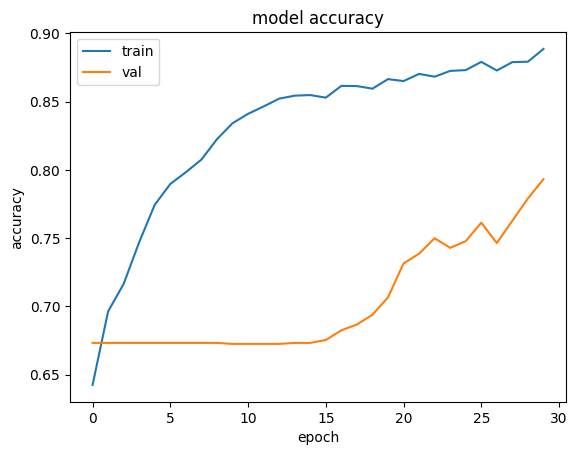

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

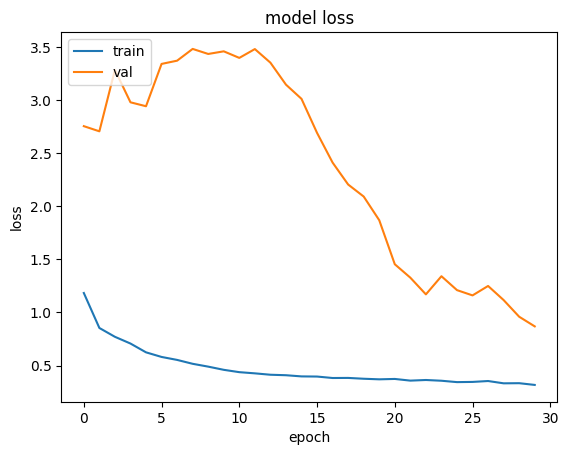

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

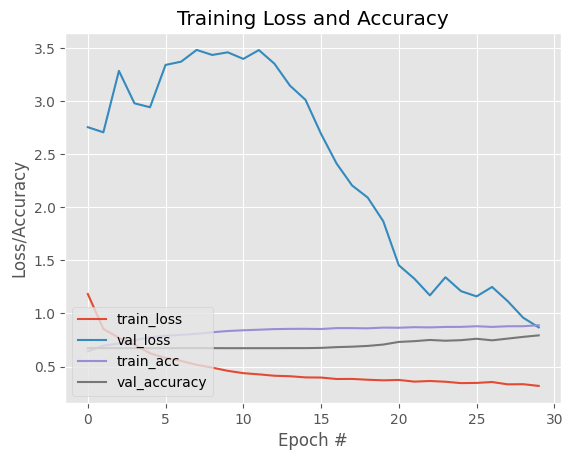

In [ ]:
N = 30
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), history.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), history.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), history.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), history.history["val_accuracy"], label="val_accuracy")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")


In [ ]:
test_data.reset()
predictions = model.predict_generator(test_data, steps=test_data.samples/test_data.batch_size,verbose=1)
y_pred= np.argmax(predictions, axis=1)

<ipython-input-31-99bdc2a40673>:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions = model.predict_generator(test_data, steps=test_data.samples/test_data.batch_size,verbose=1)


1703/1703 [==============================] - 42s 22ms/step


In [ ]:
c=np.where(y_pred == name_as_indexes_test)

In [ ]:
np.count_nonzero(c)

1304

In [ ]:
print("Test Accuracy :",(np.count_nonzero(c)/len(name_as_indexes_test))*100)

Test Accuracy : 76.57075748678803


In [ ]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(name_as_indexes_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.42      0.26      0.32        62
           1       0.51      0.68      0.58        77
           2       0.70      0.43      0.54       201
           3       0.00      0.00      0.00        24
           4       0.73      0.17      0.28       191
           5       0.80      0.98      0.88      1128
           6       0.76      0.65      0.70        20

    accuracy                           0.77      1703
   macro avg       0.56      0.45      0.47      1703
weighted avg       0.74      0.77      0.72      1703



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
history = model.fit_generator(generator=train_data,
                            steps_per_epoch=train_data.samples//train_data.batch_size,
                            validation_data=val_data,
                            verbose=1,
                            validation_steps=val_data.samples//val_data.batch_size,
                            epochs=30,callbacks=[learning_control])

<ipython-input-23-f1c102b17b87>:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(generator=train_data,


Epoch 1/30
215/215 [==============================] - 198s 826ms/step - loss: 1.0506 - accuracy: 0.6534 - val_loss: 1.8569 - val_accuracy: 0.6733 - lr: 0.0100
Epoch 2/30
215/215 [==============================] - 170s 789ms/step - loss: 0.8347 - accuracy: 0.7068 - val_loss: 1.7390 - val_accuracy: 0.6733 - lr: 0.0100
Epoch 3/30
215/215 [==============================] - 154s 717ms/step - loss: 0.7397 - accuracy: 0.7345 - val_loss: 2.0996 - val_accuracy: 0.6733 - lr: 0.0100
Epoch 4/30
215/215 [==============================] - 171s 796ms/step - loss: 0.6735 - accuracy: 0.7585 - val_loss: 1.8031 - val_accuracy: 0.6847 - lr: 0.0100
Epoch 5/30
215/215 [==============================] - 155s 722ms/step - loss: 0.6176 - accuracy: 0.7814 - val_loss: 1.7480 - val_accuracy: 0.6839 - lr: 0.0100
Epoch 6/30
215/215 [==============================] - 170s 790ms/step - loss: 0.5638 - accuracy: 0.8045 - val_loss: 1.2473 - val_accuracy: 0.7124 - lr: 0.0100
Epoch 7/30
215/215 [==========================

In [ ]:
model.save('model_mobilenetv2_2.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


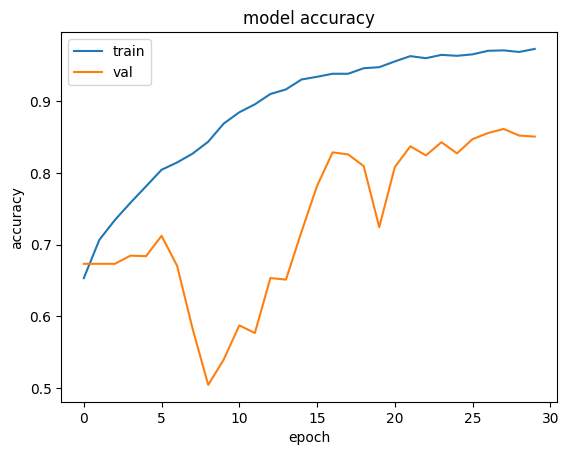

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

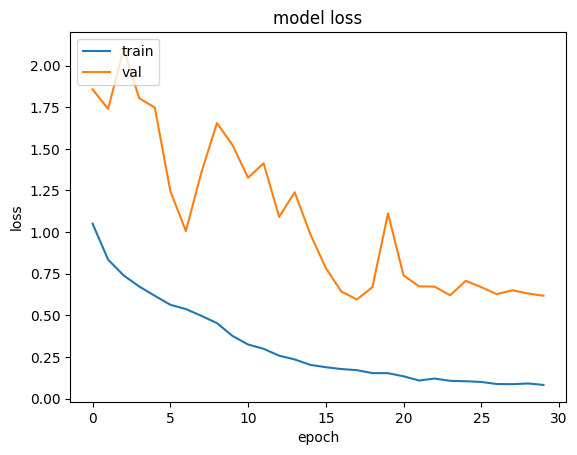

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

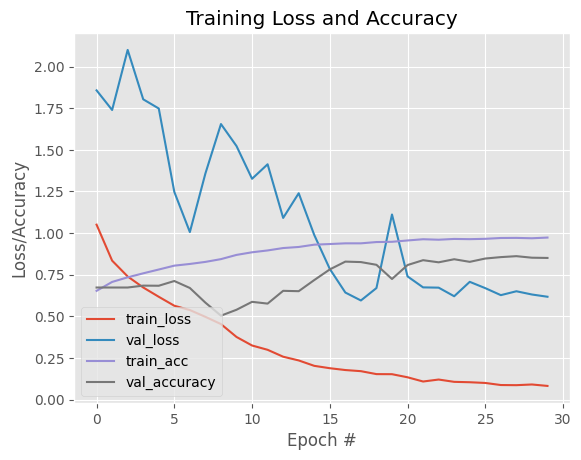

In [ ]:
N = 30
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), history.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), history.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), history.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), history.history["val_accuracy"], label="val_accuracy")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")


In [ ]:
test_data.reset()
predictions = model.predict_generator(test_data, steps=test_data.samples/test_data.batch_size,verbose=1)
y_pred= np.argmax(predictions, axis=1)

<ipython-input-28-99bdc2a40673>:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions = model.predict_generator(test_data, steps=test_data.samples/test_data.batch_size,verbose=1)


1703/1703 [==============================] - 49s 27ms/step


In [ ]:
print(y_pred)

[2 5 4 ... 5 5 5]


In [ ]:
c=np.where(y_pred == name_as_indexes_test)

In [ ]:
print("Test Accuracy :",(np.count_nonzero(c)/len(name_as_indexes_test))*100)

Test Accuracy : 83.26482677627716


In [ ]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(name_as_indexes_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.65      0.58      0.62        62
           1       0.73      0.74      0.74        77
           2       0.67      0.74      0.71       201
           3       0.69      0.46      0.55        24
           4       0.62      0.54      0.58       191
           5       0.91      0.93      0.92      1128
           6       0.79      0.95      0.86        20

    accuracy                           0.83      1703
   macro avg       0.72      0.71      0.71      1703
weighted avg       0.83      0.83      0.83      1703



# **RESNET50**

In [ ]:
from keras.optimizers import Adam,SGD
model.compile(optimizer=SGD(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history = model.fit_generator(generator=train_data,
                            steps_per_epoch=train_data.samples//train_data.batch_size,
                            validation_data=val_data,
                            verbose=1,
                            validation_steps=val_data.samples//val_data.batch_size,
                            epochs=30,callbacks=[learning_control])

<ipython-input-24-f1c102b17b87>:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(generator=train_data,


Epoch 1/30
431/431 [==============================] - 219s 455ms/step - loss: 1.0112 - accuracy: 0.6699 - val_loss: 1.1872 - val_accuracy: 0.6733 - lr: 0.0100
Epoch 2/30
431/431 [==============================] - 190s 440ms/step - loss: 0.7618 - accuracy: 0.7289 - val_loss: 0.9914 - val_accuracy: 0.6747 - lr: 0.0100
Epoch 3/30
431/431 [==============================] - 174s 403ms/step - loss: 0.6823 - accuracy: 0.7527 - val_loss: 0.6588 - val_accuracy: 0.7720 - lr: 0.0100
Epoch 4/30
431/431 [==============================] - 188s 437ms/step - loss: 0.6104 - accuracy: 0.7810 - val_loss: 0.5999 - val_accuracy: 0.7862 - lr: 0.0100
Epoch 5/30
431/431 [==============================] - 188s 437ms/step - loss: 0.5456 - accuracy: 0.8021 - val_loss: 0.7125 - val_accuracy: 0.7550 - lr: 0.0100
Epoch 6/30
431/431 [==============================] - 172s 400ms/step - loss: 0.5331 - accuracy: 0.8124 - val_loss: 0.5785 - val_accuracy: 0.7983 - lr: 0.0100
Epoch 7/30
431/431 [==========================

In [ ]:
model.save('model_resnet50_1.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


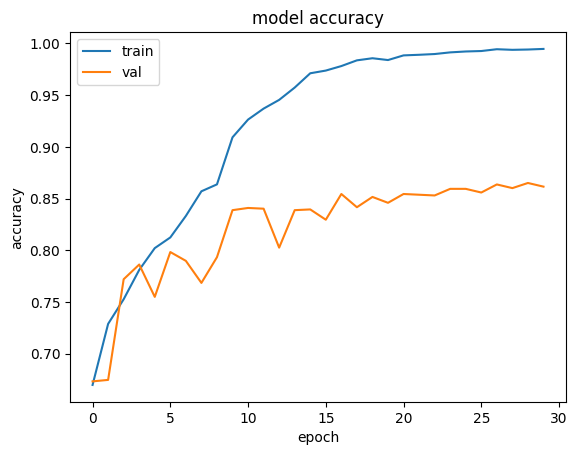

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

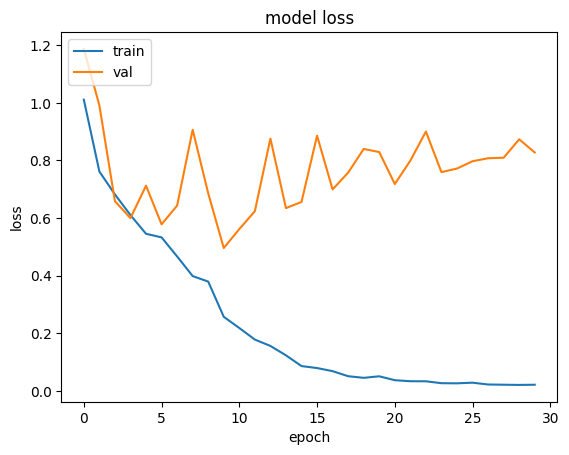

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

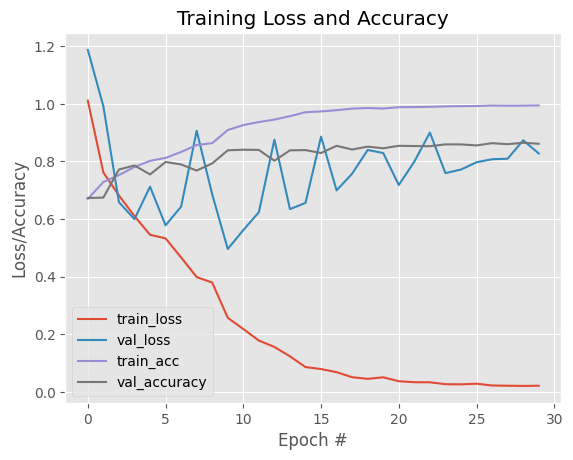

In [ ]:
N = 30
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), history.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), history.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), history.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), history.history["val_accuracy"], label="val_accuracy")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")

In [ ]:
test_data.reset()
predictions = model.predict_generator(test_data, steps=test_data.samples/test_data.batch_size,verbose=1)
y_pred= np.argmax(predictions, axis=1)

<ipython-input-29-99bdc2a40673>:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions = model.predict_generator(test_data, steps=test_data.samples/test_data.batch_size,verbose=1)


1703/1703 [==============================] - 47s 26ms/step


In [ ]:
c=np.where(y_pred == name_as_indexes_test)

In [ ]:
print("Test Accuracy :",(np.count_nonzero(c)/len(name_as_indexes_test))*100)

Test Accuracy : 85.37874339401057


In [ ]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(name_as_indexes_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.67      0.50      0.57        62
           1       0.82      0.77      0.79        77
           2       0.74      0.69      0.71       201
           3       0.75      0.50      0.60        24
           4       0.72      0.57      0.64       191
           5       0.90      0.96      0.93      1128
           6       0.77      0.85      0.81        20

    accuracy                           0.85      1703
   macro avg       0.77      0.69      0.72      1703
weighted avg       0.85      0.85      0.85      1703



# **ENSEMBLE METHOD**

In [ ]:
model_1 = load_model('/content/model_mobilenetv2_2.h5')
model_1 = Model(inputs= model_1.inputs,
                outputs= model_1.outputs,
                name = 'mobilenetv2')

In [ ]:
model_2 = load_model('/content/model_resnet50_1.h5')
model_2 = Model(inputs= model_2.inputs,
                outputs= model_2.outputs,
                name = 'resnet50')

In [ ]:
model_list = [model_1,model_2]

In [ ]:
model_input = Input(shape=(224,224,3))
model_outputs = [model(model_input) for model in model_list]
ensemble_output = Average()(model_outputs)
ensemble_model = Model(inputs = model_input, outputs = ensemble_output,name = 'ensemble')

In [ ]:
ensemble_model.compile(optimizer=SGD(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history_ens = ensemble_model.fit(train_data,
                            steps_per_epoch=train_data.samples//train_data.batch_size,
                            validation_data=val_data,
                            verbose=1,
                            validation_steps=val_data.samples//val_data.batch_size,
                            epochs=40,callbacks=[learning_control])

Epoch 1/40
431/431 [==============================] - 267s 517ms/step - loss: 0.3249 - accuracy: 0.9471 - val_loss: 0.7936 - val_accuracy: 0.8153 - lr: 0.0100
Epoch 2/40
431/431 [==============================] - 201s 467ms/step - loss: 0.1797 - accuracy: 0.9509 - val_loss: 1.5584 - val_accuracy: 0.7635 - lr: 0.0100
Epoch 3/40
431/431 [==============================] - 202s 469ms/step - loss: 0.1975 - accuracy: 0.9396 - val_loss: 0.6594 - val_accuracy: 0.8232 - lr: 0.0100
Epoch 4/40
431/431 [==============================] - 201s 467ms/step - loss: 0.1728 - accuracy: 0.9454 - val_loss: 1.1335 - val_accuracy: 0.7557 - lr: 0.0100
Epoch 5/40
431/431 [==============================] - 215s 498ms/step - loss: 0.1512 - accuracy: 0.9506 - val_loss: 0.8496 - val_accuracy: 0.8168 - lr: 0.0100
Epoch 6/40
431/431 [==============================] - ETA: 0s - loss: 0.1346 - accuracy: 0.9593
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
431/431 [=========================

In [ ]:
import os
if os.path.exists('model_final2.h5'):
    os.remove('model_final2.h5')
ensemble_model.save('model_final2.h5')


ValueError: Unable to create dataset (name already exists)

In [ ]:
c=np.where(y_pred == name_as_indexes_test)

In [ ]:
print("Test Accuracy :",(np.count_nonzero(c)/len(name_as_indexes_test))*100)

Test Accuracy : 86.43570170287728


In [ ]:
test_data.reset()
predictions = ensemble_model.predict_generator(test_data, steps=test_data.samples/test_data.batch_size,verbose=1)
y_pred= np.argmax(predictions, axis=1)

<ipython-input-32-a23616434846>:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions = ensemble_model.predict_generator(test_data, steps=test_data.samples/test_data.batch_size,verbose=1)


1703/1703 [==============================] - 78s 41ms/step


In [ ]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(name_as_indexes_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.58      0.52      0.55        62
           1       0.73      0.83      0.78        77
           2       0.77      0.65      0.70       201
           3       0.72      0.54      0.62        24
           4       0.79      0.62      0.69       191
           5       0.91      0.97      0.94      1128
           6       0.90      0.90      0.90        20

    accuracy                           0.86      1703
   macro avg       0.77      0.72      0.74      1703
weighted avg       0.86      0.86      0.86      1703



In [ ]:
from sklearn.metrics import confusion_matrix

# Assuming you have actual labels (y_true) and predicted labels (y_pred)
cm = confusion_matrix(name_as_indexes_test, y_pred)

# Print the confusion matrix
print(cm)


[[  32   10    6    1    4    9    0]
 [   5   64    1    1    3    3    0]
 [  11    4  130    2   13   41    0]
 [   3    3    3   13    0    2    0]
 [   3    2   16    0  118   51    1]
 [   1    5   12    1   11 1097    1]
 [   0    0    0    0    0    2   18]]


In [ ]:
import matplotlib.pyplot as plt


# Assuming you have the following from your initial code:
# - test: The pandas DataFrame containing test data (image filenames and labels)
# - destination_folder: The directory containing the images
# - ensemble_model: Your trained model
# - encoder (optional): The label encoder if you used it

def get_image_path(filename):
  # Assuming filenames are in 'image_full_name' column
  return os.path.join(destination_folder, filename)

# Assuming class labels are encoded, get class names if necessary
if 'label' in test.columns:
  class_names = encoder.inverse_transform(test['label'])  # Decode labels if encoded
else:
  # If labels weren't encoded, use them directly (assuming they are class names)
  class_names = test['dx'].tolist()  # Assuming diagnosis labels are in 'dx' column

num_images_to_print = 15  # Number of images to display

# Loop through the test data
for i in range(num_images_to_print):
  image_filename = test.loc[i, 'image_full_name']  # Access filename from DataFrame
  image_path = get_image_path(image_filename)  # Construct image path

  # Load the image (replace with your image loading method)
  image = cv2.imread(image_path)  # Assuming OpenCV is used for image loading

  # Preprocess the image if necessary (resize, normalization, etc.)
  image = cv2.resize(image, (224, 224))  # Assuming resizing to 224x224
  image = image.astype('float32') / 255.0  # Assuming normalization

  # Reshape the image for prediction (might need adjustments)
  image = np.expand_dims(image, axis=0)  # Add a batch dimension

  prediction = ensemble_model.predict(image)[0]
  predicted_class_index = np.argmax(prediction)

  # Plot the image and predicted class
  plt.imshow(image[0])  # Assuming image is a 3-channel array
  plt.title(f"Predicted Class: {class_names[predicted_class_index]}")
  plt.axis('off')
  plt.show()


NameError: name 'cv2' is not defined

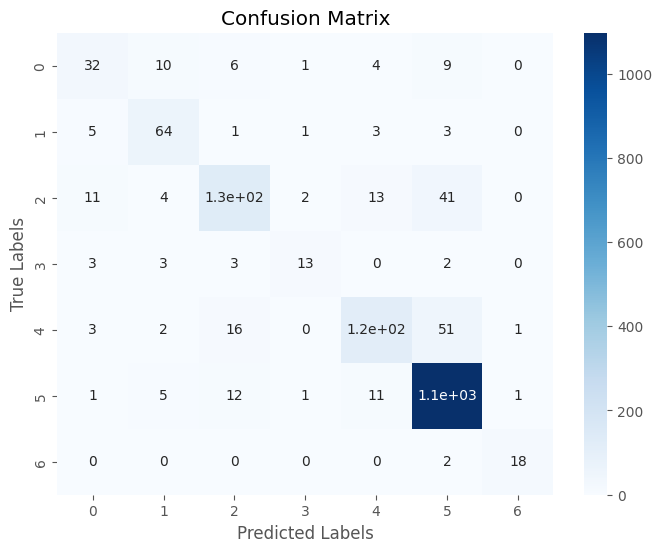

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have the confusion matrix (cm)
# You can obtain it using methods from previous examples

# Create a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues")  # Adjust 'cmap' for different color schemes

# Add labels and title
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

# Show the plot
plt.show()


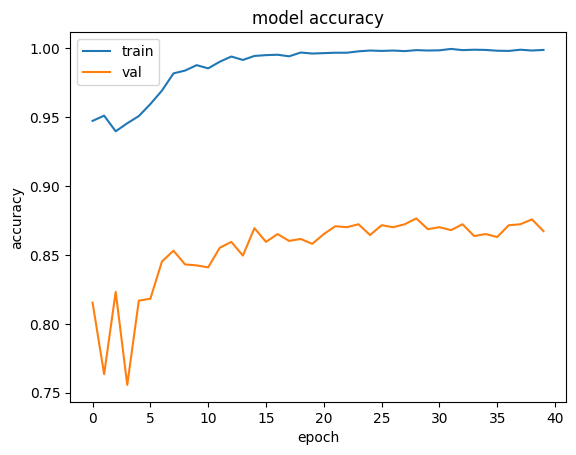

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history_ens.history['accuracy'])
plt.plot(history_ens.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

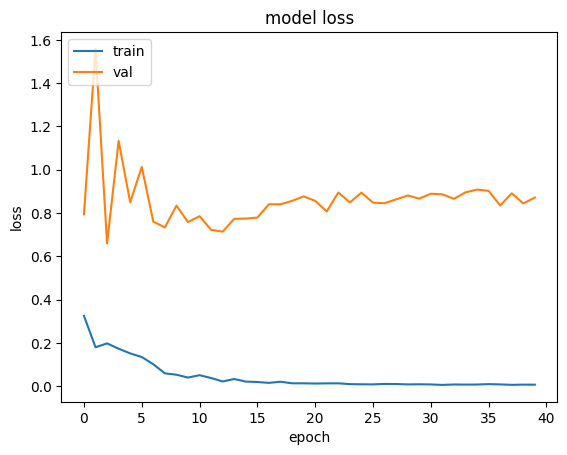

In [ ]:
plt.plot(history_ens.history['loss'])
plt.plot(history_ens.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

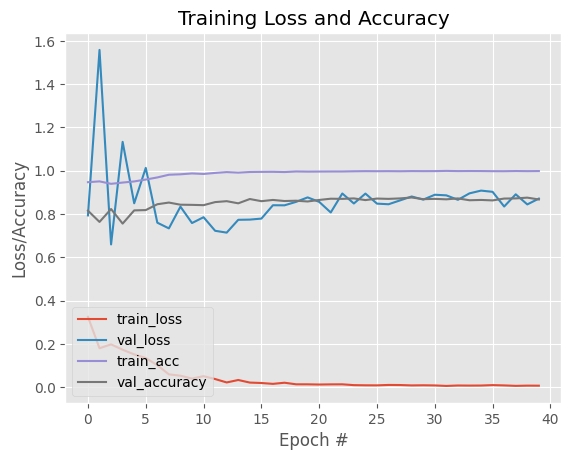

In [ ]:
N = 40
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), history_ens.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), history_ens.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), history_ens.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), history_ens.history["val_accuracy"], label="val_accuracy")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")

# **DENSENET 169**

In [ ]:
from keras.optimizers import Adam,SGD
model.compile(optimizer=SGD(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history_dense = model.fit_generator(generator=train_data,
                            steps_per_epoch=train_data.samples//train_data.batch_size,
                            validation_data=val_data,
                            verbose=1,
                            validation_steps=val_data.samples//val_data.batch_size,
                            epochs=30,callbacks=[learning_control])

<ipython-input-26-bb52935ea3ed>:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history_dense = model.fit_generator(generator=train_data,


Epoch 1/30
431/431 [==============================] - 253s 503ms/step - loss: 1.0974 - accuracy: 0.6459 - val_loss: 1.4702 - val_accuracy: 0.6733 - lr: 0.0100
Epoch 2/30
431/431 [==============================] - 195s 453ms/step - loss: 0.8981 - accuracy: 0.6712 - val_loss: 1.0187 - val_accuracy: 0.6733 - lr: 0.0100
Epoch 3/30
431/431 [==============================] - 205s 476ms/step - loss: 0.8498 - accuracy: 0.6774 - val_loss: 0.7986 - val_accuracy: 0.6889 - lr: 0.0100
Epoch 4/30
431/431 [==============================] - 192s 445ms/step - loss: 0.7994 - accuracy: 0.6914 - val_loss: 0.8248 - val_accuracy: 0.7145 - lr: 0.0100
Epoch 5/30
431/431 [==============================] - 204s 473ms/step - loss: 0.7664 - accuracy: 0.7174 - val_loss: 0.7752 - val_accuracy: 0.7180 - lr: 0.0100
Epoch 6/30
431/431 [==============================] - 193s 446ms/step - loss: 0.7365 - accuracy: 0.7344 - val_loss: 0.8321 - val_accuracy: 0.7159 - lr: 0.0100
Epoch 7/30
431/431 [==========================

In [ ]:
model.save('model_densenet_1.h5')

NameError: name 'model' is not defined

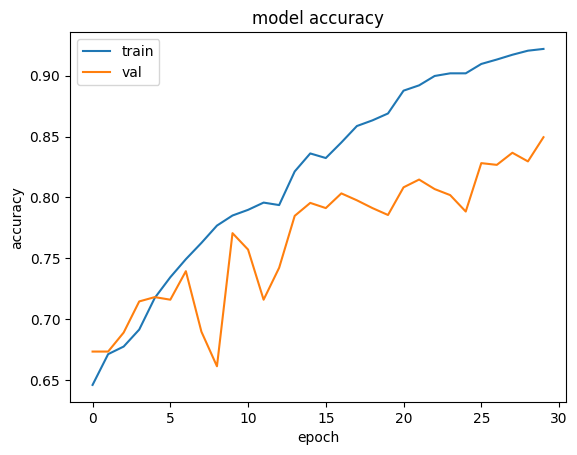

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history_dense.history['accuracy'])
plt.plot(history_dense.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

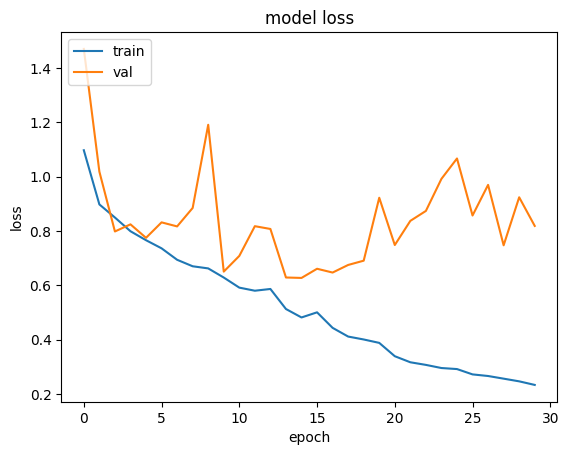

In [ ]:
plt.plot(history_dense.history['loss'])
plt.plot(history_dense.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

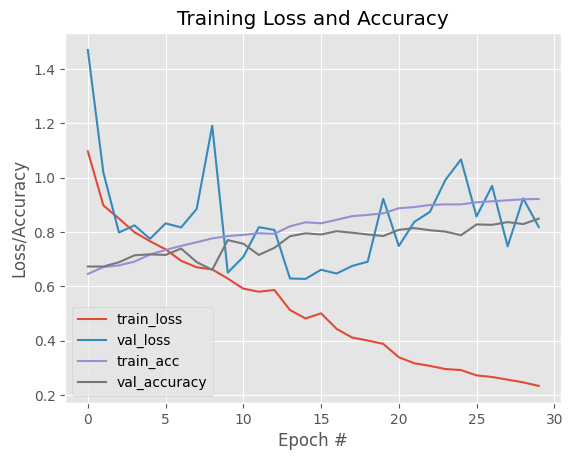

In [ ]:
N = 30
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), history_dense.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), history_dense.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), history_dense.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), history_dense.history["val_accuracy"], label="val_accuracy")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")

In [ ]:
c=np.where(y_pred == name_as_indexes_test)

In [ ]:
test_data.reset()
predictions = model.predict_generator(test_data, steps=test_data.samples/test_data.batch_size,verbose=1)
y_pred= np.argmax(predictions, axis=1)

<ipython-input-33-99bdc2a40673>:2: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions = model.predict_generator(test_data, steps=test_data.samples/test_data.batch_size,verbose=1)


1703/1703 [==============================] - 48s 27ms/step


In [ ]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(name_as_indexes_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.61      0.40      0.49        62
           1       0.50      0.81      0.62        77
           2       0.70      0.67      0.69       201
           3       0.00      0.00      0.00        24
           4       0.38      0.59      0.46       191
           5       0.90      0.83      0.86      1128
           6       0.00      0.00      0.00        20

    accuracy                           0.75      1703
   macro avg       0.44      0.47      0.44      1703
weighted avg       0.76      0.75      0.75      1703



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
print("Test Accuracy :",(np.count_nonzero(c)/len(name_as_indexes_test))*100)

Test Accuracy : 74.69172049324722


In [ ]:
from google.colab import drive
drive.mount('/content/drive')